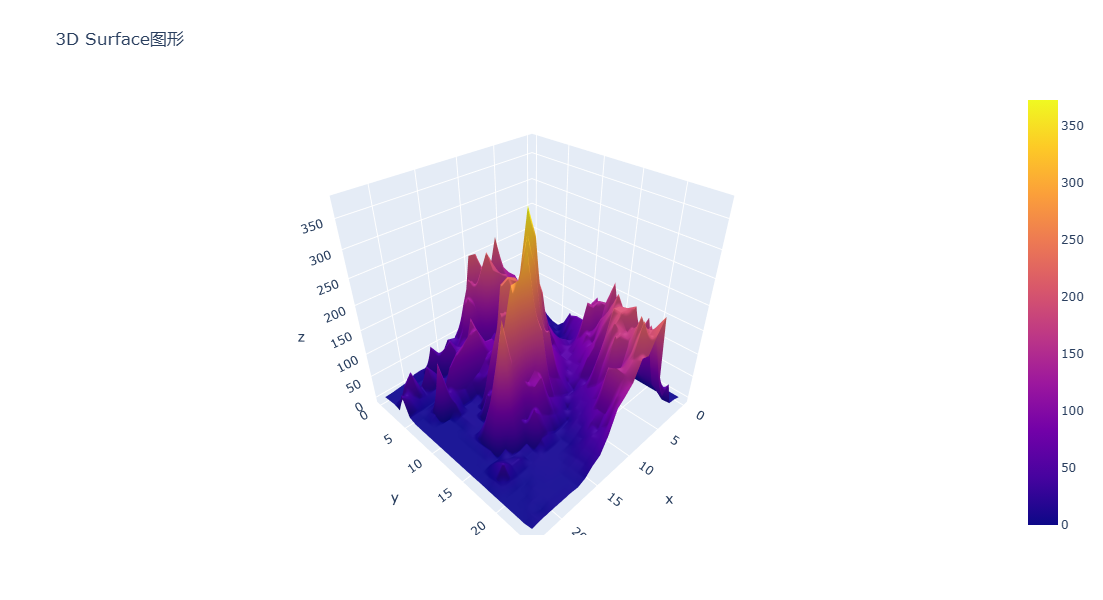

In [4]:
import plotly.graph_objects as go

import pandas as pd

# 读取高程数据csv文件
z_data = pd.read_csv('mt_bruno_elevation.csv',
                     index_col=0)  # index_col参数表示将第一列的数据当做索引
z_data.head()
fig = go.Figure(data=[go.Surface(z=z_data.values)])

fig.update_layout(title="3D Surface图形", # 标题
                  autosize=False,  # 尺度自动缩放
                  width=700,  # 长宽
                  height=600,
                  margin=dict(l=65,r=50,b=65,t=90)  # 4个位置的距离
                 )

fig.show()

高程数据样例：
         0         1         2         3         4         5         6   \
0  0.640013  0.633204  0.670020  0.839207  0.449931  0.378853  0.380092   
1  0.701593  0.590797  0.564001  0.378413  0.367684  0.265093  0.251971   
2  0.324136  0.681602  0.504957  0.391234  0.302446  0.321288  0.288260   
3  0.421893  0.383780  0.502766  0.243331  0.197189  0.367056  0.189527   
4  0.390255  0.193577  0.443400  0.166124  0.054256  0.156095  0.028571   

         7         8         9   ...        90        91        92        93  \
0  0.253668  0.243862 -0.044579  ...  0.259939  0.094751  0.112257  0.362132   
1  0.264956  0.145830 -0.090788  ...  0.000111  0.301536  0.245068  0.335250   
2  0.059368  0.251425  0.051554  ... -0.047765 -0.015364  0.315473  0.054614   
3  0.214763  0.157864  0.135875  ...  0.036312  0.030753  0.218853  0.264060   
4 -0.177292 -0.044534 -0.027712  ... -0.086638 -0.036456 -0.068060  0.069305   

         94        95        96        97        98        9

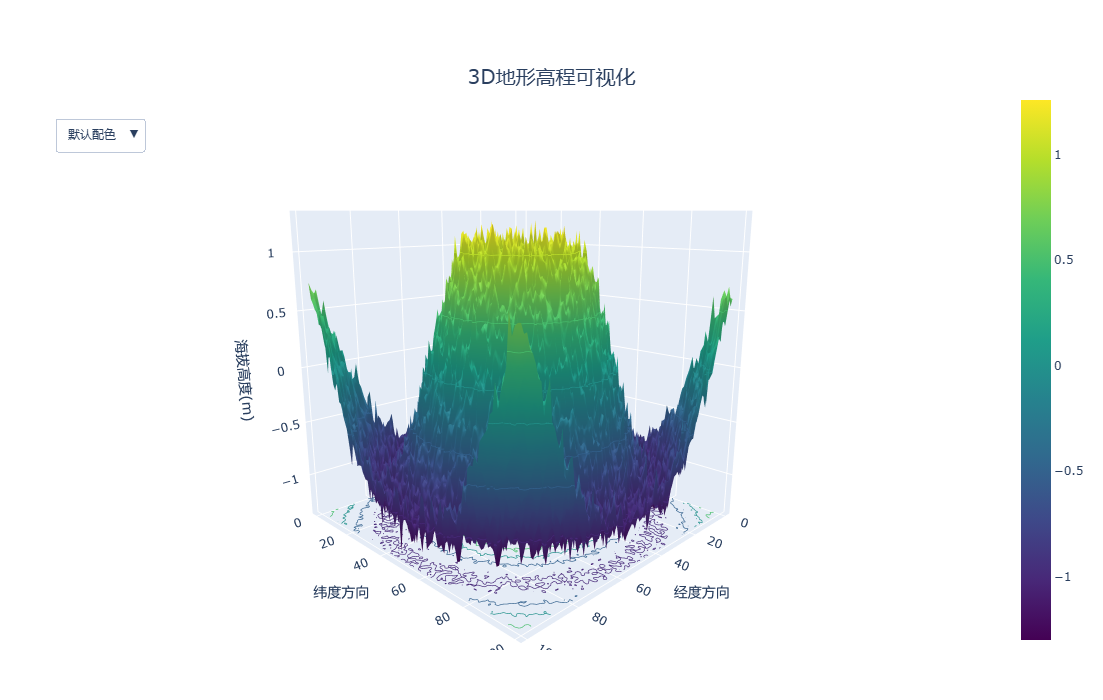

In [14]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

"""
3D曲面图绘制工具
功能：使用Plotly绘制交互式3D地形曲面图
数据集说明：默认使用Mt.Bruno高程数据，也可替换为自定义数据
"""

# ==================== 数据准备 ==================== 
# 使用模拟数据
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2)) + np.random.normal(0, 0.1, X.shape)
z_data = pd.DataFrame(Z)

# 查看数据前5行
print("高程数据样例：")
print(z_data.head())

# ==================== 图形绘制 ====================
# 创建3D曲面图
fig = go.Figure(
    data=[go.Surface(
        z=z_data.values,  # 高程数据
        colorscale='Viridis',  # 颜色方案
        contours={  # 等高线设置
            "z": {
                "show": True,
                "usecolormap": True,
                "highlightcolor": "limegreen",
                "project_z": True
            }
        }
    )]
)

# ==================== 布局设置 ====================
fig.update_layout(
    title={
        'text': "3D地形高程可视化",  # 主标题
        'y':0.9,  # 标题位置（0-1）
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}  # 标题字体
    },
    scene={
        "xaxis_title": "经度方向",
        "yaxis_title": "纬度方向", 
        "zaxis_title": "海拔高度(m)",
        "camera_eye": {"x": 1.5, "y": 1.5, "z": 0.5}  # 初始视角
    },
    autosize=False,
    width=800,  # 画布尺寸
    height=700,
    margin=dict(l=50, r=50, b=50, t=90),  # 边距
    coloraxis_colorbar={
        'title': '海拔高度',
        'thickness': 20,
        'len': 0.75
    }
)

# ==================== 交互功能 ====================
# 添加自定义按钮
fig.update_layout(
    updatemenus=[
        {
            "buttons": [
                {
                    "args": [{"colorscale": "Viridis"}],
                    "label": "默认配色",
                    "method": "update"
                },
                {
                    "args": [{"colorscale": "Plasma"}],
                    "label": "高温配色",
                    "method": "update"
                },
                {
                    "args": [{"colorscale": "Inferno"}],
                    "label": "Inferno",
                    "method": "update"
                },
                {
                    "args": [{"colorscale": "Cividis"}],
                    "label": "Cividis",
                    "method": "update"
                },
                {
                    "args": [{"colorscale": "RdBu"}],
                    "label": "RdBu",
                    "method": "update"
                },
                {
                    "args": [{"colorscale": "lifeExp"}],
                    "label": "lifeExp",
                    "method": "update"
                }
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.1,
            "y": 0.95
        }
    ]
)

# ==================== 使用说明 ====================
"""
使用说明：
1. 鼠标操作：
   - 左键拖动：旋转视角
   - 右键拖动：平移视图
   - 滚轮缩放：放大/缩小

2. 工具栏功能（右上角）：
   - 下载图片
   - 缩放/平移模式切换
   - 重置视角
   - 切换全屏

3. 数据替换：
   - 替换z_data为您的DataFrame格式数据
   - 确保数据为矩形网格数值
"""

# 显示图形
fig.show()

数据字段说明：
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


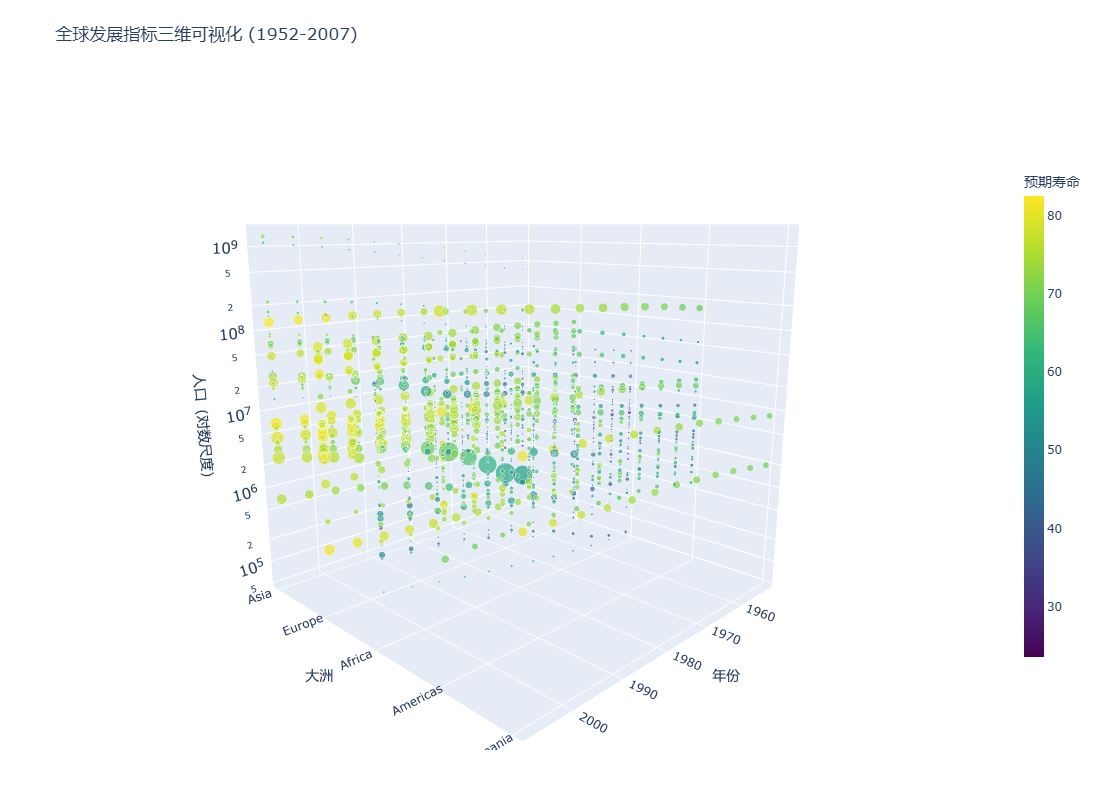

'\n数据解读建议：\n1. 气泡大小反映国家富裕程度（人均GDP）\n2. 颜色深浅反映国民健康水平（预期寿命）\n3. 随时间变化（X轴）可观察发展趋势\n4. 对数尺度能更好展示人口差异（避免个别大国主导视图）\n'

In [10]:
import plotly.express as px

# 加载数据集（gapminder全球发展指标数据集）
# 数据集包含：国家名称、年份、人口、GDP、预期寿命等指标
data = px.data.gapminder()  
print("数据字段说明：")
print(data.head())  # 打印前5行查看数据结构

"""
创建3D散点图
参数说明：
- x/y/z: 分别对应三维坐标轴的字段
- size: 气泡大小映射的字段（建议使用连续数值变量）
- color: 颜色映射的字段（可使用连续或离散变量）
- hover_data: 鼠标悬停时显示的附加信息
- log_scale: 自动对指定轴取对数（替代原update_layout方案）
- range_*: 控制坐标轴显示范围
"""
fig = px.scatter_3d(
    data,
    x='year',           # X轴：年份（1952-2007）
    y='continent',      # Y轴：大洲（分类数据）
    z='pop',            # Z轴：人口数量（线性/对数）
    size='gdpPercap',   # 气泡大小：人均GDP（美元）
    color='lifeExp',    # 颜色：预期寿命（岁）
    color_continuous_scale='Viridis',  # 连续色标方案
    size_max=30,        # 最大气泡尺寸（像素）
    hover_name='country',  # 主悬停标签
    hover_data={
        'year': False,  # 隐藏重复的年份信息
        'gdpPercap': ':.2f',  # GDP显示2位小数
        'lifeExp': ':.1f'     # 预期寿命显示1位小数
    },
    log_z=True,         # 自动对Z轴取对数（替代原update_layout方案）
    height=800,         # 画布高度
    title='全球发展指标三维可视化 (1952-2007)'  # 图表标题
)

"""
高级布局设置
"""
fig.update_layout(
    scene=dict(
        xaxis_title='年份',
        yaxis_title='大洲',
        zaxis_title='人口（对数尺度）',
        zaxis=dict(
            type='log',  # 确保Z轴对数显示
            exponentformat='power'  # 科学计数法显示
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.5)  # 初始视角
        )
    ),
    coloraxis_colorbar=dict(
        title='预期寿命',
        thickness=20,
        len=0.75
    ),
    margin=dict(l=50, r=50, b=50, t=80)  # 边距调整
)

"""
交互功能说明：
1. 鼠标操作：
   - 左键拖动：旋转视角
   - 右键拖动：平移视图
   - 滚轮缩放：Z轴缩放
   - 点击图例：显示/隐藏分类

2. 工具栏（右上角）：
   - 下载PNG
   - 缩放/平移模式切换
   - 重置视角
   - 切换全屏
"""

# 显示图形
fig.show()

"""
数据解读建议：
1. 气泡大小反映国家富裕程度（人均GDP）
2. 颜色深浅反映国民健康水平（预期寿命）
3. 随时间变化（X轴）可观察发展趋势
4. 对数尺度能更好展示人口差异（避免个别大国主导视图）
"""

In [52]:
import plotly.graph_objects as go
import numpy as np

# 生成螺旋线数据
N = 100
t = np.linspace(0, 20, N)
x, y, z = np.cos(t), np.sin(t), t

# 创建3D散点图
fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers+lines',
    marker=dict(
        size=8,
        color=z,
        colorscale='Plasma',
        opacity=0.9,
        colorbar=dict(
            title='高度值',
            titlefont=dict(color='white'),
            tickfont=dict(color='white')
        )
    ),
    line=dict(
        color='rgba(150, 150, 150, 0.4)',
        width=3
    )
)]) 

# 布局设置
fig.update_layout(
    scene=dict(
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.8),
            up=dict(x=0, y=0, z=1)
        ),
        xaxis=dict(
            title='X轴',
            titlefont=dict(color='#FF6E6E'),
            tickfont=dict(color='#FFAAAA'),
            gridcolor='rgba(255, 255, 255, 0.1)',
            linecolor='#FF6E6E' # 设置X轴颜色
        ),
        yaxis=dict(
            title='Y轴',
            titlefont=dict(color='#6EFF6E'),
            tickfont=dict(color='#AAFFAA'),
            gridcolor='rgba(255, 255, 255, 0.1)',
            linecolor='#6EFF6E' # 设置Y轴颜色
        ),
        zaxis=dict(
            title='Z轴',
            titlefont=dict(color='#6E6EFF'),
            tickfont=dict(color='#AAAAFF'),
            gridcolor='rgba(255, 255, 255, 0.1)',
            linecolor='#6E6EFF' # 设置Z轴颜色
        ),
        bgcolor='#ffffff' # 设置画布背景颜色
    ),
    title={
        'text': "3D螺旋线可视化",
        'y':0.95,
        'x':0.5,
        'font': dict(size=24, color='white', family="Arial")
    },
    paper_bgcolor='#6E6EFF', 
    margin=dict(l=20, r=20, b=20, t=40)
)

fig.show()

# 指定图片尺寸，修改背景颜色

In [51]:
import plotly.graph_objects as go
import numpy as np

# 生成螺旋线数据
N = 100
t = np.linspace(0, 20, N)
x, y, z = np.cos(t), np.sin(t), t

fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers+lines',
    marker=dict(
        size=8,
        color=z,
        colorscale='Plasma',
        opacity=0.9
    ),
    line=dict(
        color='rgba(150, 150, 150, 0.4)',
        width=3
    )
)])

# 设置坐标平面颜色
fig.update_layout(
    # 画布设置（顶层参数）
    width=1000,          # 画布宽度
    height=800,          # 画布高度
    autosize=False,      # 禁用自动缩放
    scene=dict(
        # 三个坐标平面颜色设置
        xaxis=dict(
            title='X轴',
            backgroundcolor="rgba(255, 100, 100, 0.9)",  # 浅红色
            showbackground=True,
            gridcolor="rgba(200, 200, 200, 0.5)",
            linecolor="red"
        ),
        yaxis=dict(
            title='Y轴',
            backgroundcolor="rgba(100, 255, 100, 0.9)",  # 浅绿色
            showbackground=True,
            gridcolor="rgba(200, 200, 200, 0.5)",
            linecolor="green"
        ),
        zaxis=dict(
            title='Z轴',
            backgroundcolor="rgba(100, 100, 255, 0.9)",  # 浅蓝色
            showbackground=True,
            gridcolor="rgba(200, 200, 200, 0.5)",
            linecolor="blue"
        ),
        # 场景全局设置
        bgcolor='#ffffff',  # 背景色
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))
    ),
    title="3D坐标平面颜色设置示例",
    margin=dict(l=20, r=20, b=20, t=40)
)

fig.show()

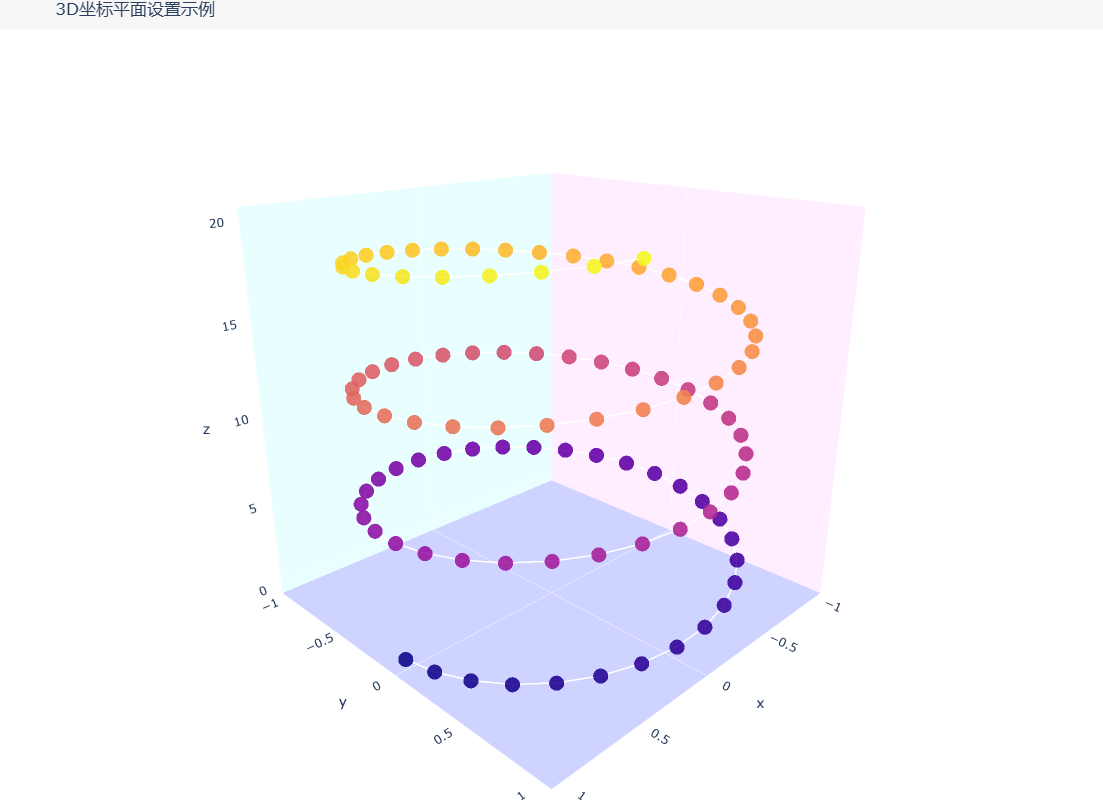

In [59]:
# 导入必要的库
import plotly.graph_objects as go  # Plotly的图形对象接口
import numpy as np  # 数值计算库

# ========== 数据生成部分 ==========
# 生成100个均匀分布的时间点（0到20之间）
N = 100  # 数据点数量
t = np.linspace(0, 20, N)  # 生成线性间隔数组

# 创建螺旋线数据：
# x = cos(t), y = sin(t), z = t
# 这会产生一个沿z轴上升的螺旋线
x, y, z = np.cos(t), np.sin(t), t

# ========== 图形创建部分 ==========
# 创建3D散点图+线图组合
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,  # 设置xyz坐标数据
    
    # 显示模式：同时显示标记点和连线
    mode='markers+lines',
    
    # 标记点样式设置
    marker=dict(
        size=8,  # 点的大小
        color=z,  # 颜色基于z值（高度）
        colorscale='Plasma',  # 使用Plasma颜色映射
        opacity=0.9  # 90%不透明度
    ),
    
    # 连线样式设置
    line=dict(
        color='rgba(150,150,150,0.4)',  # 灰色半透明连线
        width=3  # 线宽
    )
)])

# ========== 布局设置部分 ==========
fig.update_layout(
    # === 画布全局设置 ===
    width=1000,          # 画布宽度像素
    height=800,          # 画布高度像素
    autosize=False,      # 禁用自动调整大小
    paper_bgcolor='rgb(247,247,247)',  # 画布外围背景色（浅灰色）
    margin=dict(l=0, r=0, b=0, t=30),  # 设置边距（左/右/下/上）
    
    # === 3D场景专属设置 ===
    scene=dict(
        # 3D场景的背景色（整个3D空间的背景）
        bgcolor='rgba(255,255,255,1)',  # 纯白色
        
        # ---- X轴平面设置 ----
        xaxis=dict(
            showbackground=True,  # 显示背景平面
            backgroundcolor="rgba(254, 212, 245, 0.9)",  # 浅粉色平面
            # gridcolor="rgba(255,255,255,0.3)",  # 白色半透明网格线
            showgrid=False,
        ),
        
        # ---- Y轴平面设置 ----
        yaxis=dict(
            showbackground=True,
            backgroundcolor="rgba(207, 255, 232, 0.9)",  # 浅绿色平面
            # gridcolor="rgba(255,255,255,0.3)",
            showgrid=False,
        ),
        
        # ---- Z轴平面设置 ----
        zaxis=dict(
            showbackground=True,
            backgroundcolor="rgba(182, 185, 255, 0.9)",  # 浅蓝色平面
            # gridcolor="rgba(255,255,255,0.3)",
            showgrid=False,
        ),
        
        # ---- 相机视角设置 ----
        camera=dict(
            # 相机位置（眼睛坐标）
            eye=dict(x=1.5, y=1.5, z=0.8),  # 右前上方视角
            # 相机的"上"方向（z轴朝上）
            up=dict(x=0, y=0, z=1)
        )
    ),
    
    # 图表主标题
    title="3D坐标平面设置示例"
)

# 显示图形
fig.show()

# 蚕蛹图

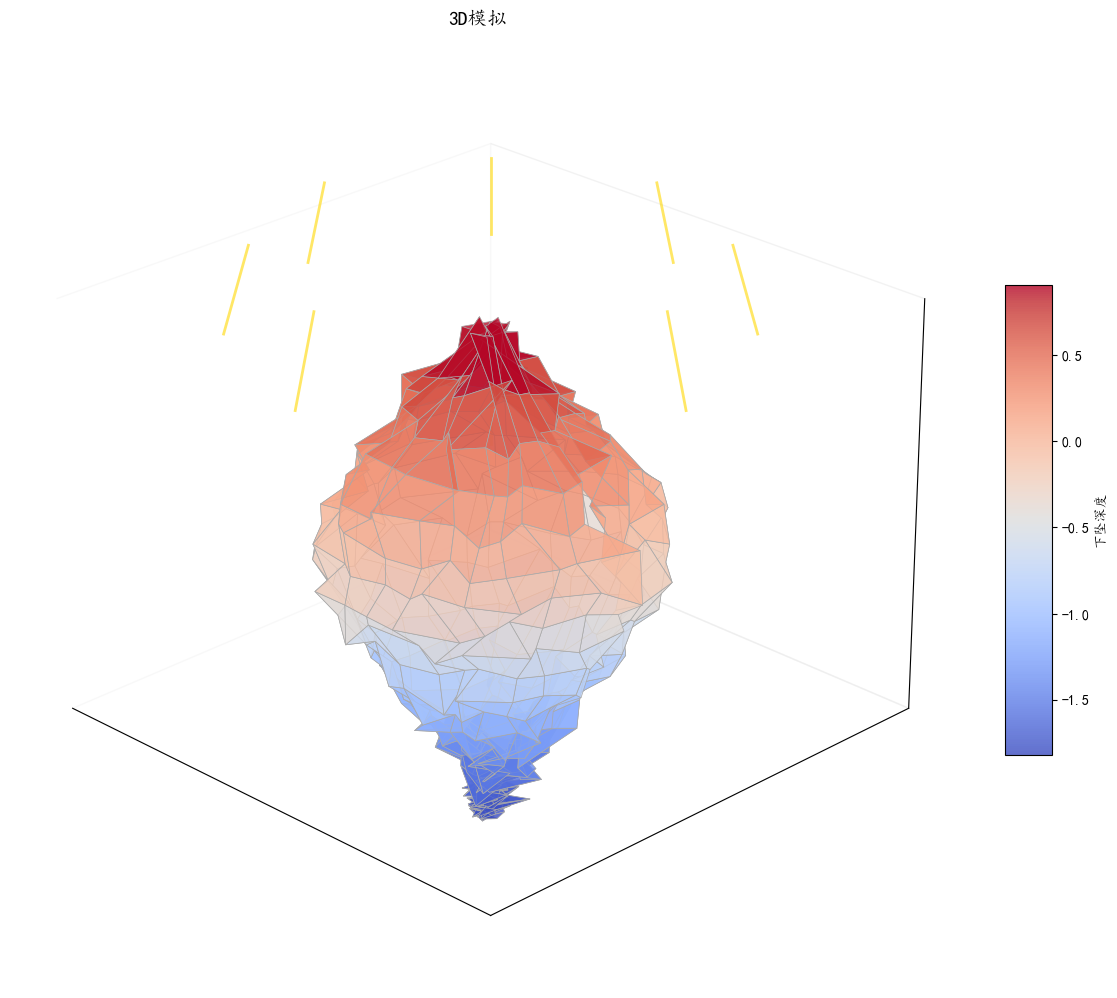

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.font_manager as fm
# 设置字体路径
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 创建网格数据
u = np.linspace(0, 2*np.pi, 30)  # 圆周方向网格点
v = np.linspace(0, np.pi, 20)    # 径向网格点
U, V = np.meshgrid(u, v)

# 基础形状（球坐标系转笛卡尔坐标系）
R = 1.0  # 初始半径
X = R * np.cos(U) * np.sin(V)
Y = R * np.sin(U) * np.sin(V)
Z = R * np.cos(V)

# 添加下坠变形效果
Z = Z - 0.8 * (1 - np.exp(-2*V))  # 指数衰减实现下坠效果
X = X * (0.5 + 0.5 * np.cos(V))   # 底部收缩
Y = Y * (0.5 + 0.5 * np.cos(V))

# 添加随机扰动模拟布料质感
np.random.seed(42)
X += 0.05 * np.random.randn(*X.shape)
Y += 0.05 * np.random.randn(*Y.shape)
Z += 0.03 * np.random.randn(*Z.shape)

# 创建图形
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制网兜表面
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.coolwarm,          # 冷暖色渐变
    linewidth=0.5,             # 网格线宽度
    edgecolor='darkgrey',      # 网格线颜色
    alpha=0.8,                # 透明度
    rstride=1, cstride=1,     # 网格密度
    antialiased=True
)

# 添加垂直线模拟悬挂点
for theta in np.linspace(0, 2*np.pi, 8, endpoint=False):
    ax.plot(
        [0.9*np.cos(theta), np.cos(theta)],
        [0.9*np.sin(theta), np.sin(theta)],
        [1.5, 1.0],
        color='gold', linewidth=2, alpha=0.6
    )

# 设置视角和光照效果
ax.view_init(elev=25, azim=-45)  # 视角设置
ax.set_zlim(-1.2, 1.2)

# 添加颜色条
fig.colorbar(surf, shrink=0.5, aspect=10, label='下坠深度')

# 美化设置
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_facecolor('white')       # 背景色
ax.xaxis.pane.fill = False      # 透明坐标平面
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)                  # 隐藏网格

plt.title("3D模拟", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

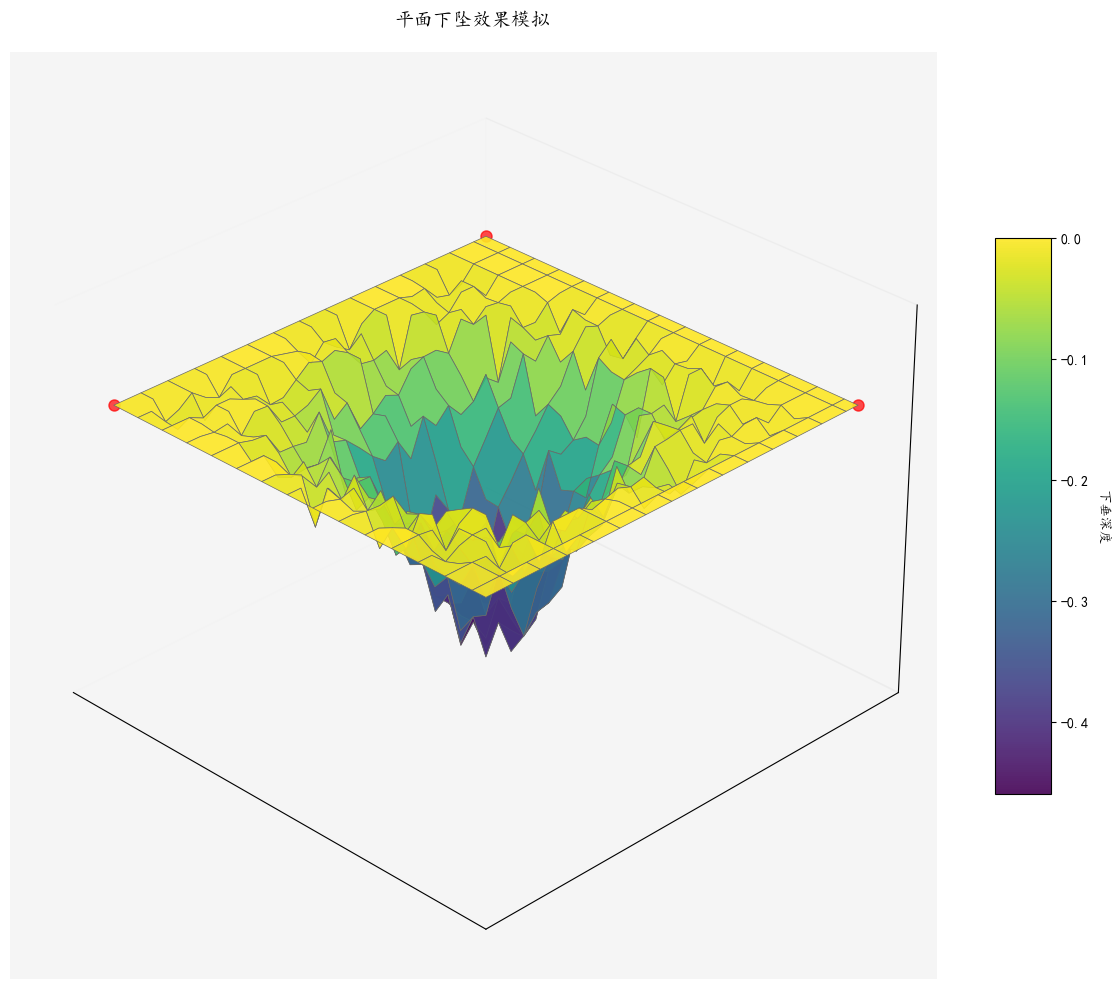

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.font_manager as fm
# 设置字体路径
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 创建平面网格
x = np.linspace(-1, 1, 30)
y = np.linspace(-1, 1, 30)
X, Y = np.meshgrid(x, y)

# 初始平面（Z=0）
Z = np.zeros_like(X)

# 添加下坠效果（中心下垂，边缘固定）
def gravity_deform(x, y):
    r = np.sqrt(x**2 + y**2)
    return -0.5 * np.exp(-5*(x**2 + y**2))  # 高斯下垂

Z = gravity_deform(X, Y)

# 添加布料褶皱效果
np.random.seed(42)
Z += 0.03 * np.random.randn(*Z.shape)  # 随机噪声
Z = np.minimum(Z, 0)  # 确保不下凸

# 固定边缘（边缘不下垂）
edge_mask = (np.abs(X) > 0.9) | (np.abs(Y) > 0.9)
Z[edge_mask] = 0

# 创建图形
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制下坠表面
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,           # 使用Viridis配色
    linewidth=0.5,             # 网格线宽度
    edgecolor='dimgray',       # 网格线颜色
    alpha=0.9,                # 透明度
    rstride=2, cstride=2,     # 网格密度
    antialiased=True
)

# 添加固定边缘的钉子效果
for x_edge in [-1, 1]:
    for y_edge in [-1, 1]:
        ax.plot(
            [x_edge], [y_edge], [0],
            'o', markersize=8, 
            color='red', alpha=0.7
        )

# 设置视角
ax.view_init(elev=30, azim=-45)
ax.set_zlim(-0.6, 0.2)

# 美化设置
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.set_facecolor('whitesmoke')  # 浅灰背景

plt.title("平面下坠效果模拟", fontsize=14, pad=20)
plt.tight_layout()

# 添加颜色条表示下垂深度
cbar = fig.colorbar(surf, shrink=0.6, aspect=10)
cbar.set_label('下垂深度', rotation=270, labelpad=15)

plt.show()

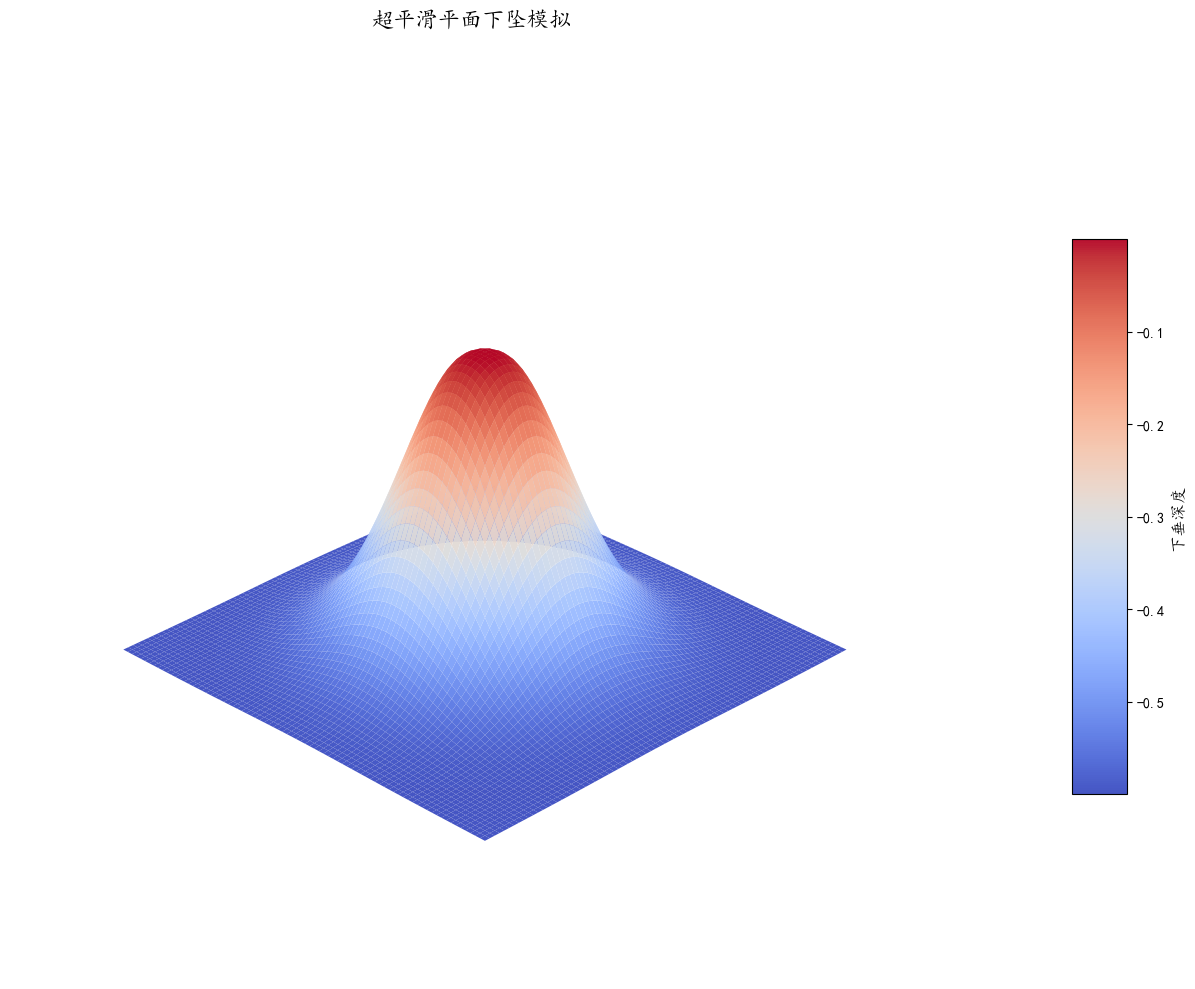

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 创建高分辨率网格
x = np.linspace(-1, 1, 80)  # 增加网格点数
y = np.linspace(-1, 1, 80)
X, Y = np.meshgrid(x, y)

# 平滑下坠函数（使用双曲正切tanh实现自然过渡）
def smooth_deform(x, y):
    r = np.sqrt(x**2 + y**2)
    return -0.6 * np.tanh(5 * r)  # tanh函数确保边缘平滑过渡

Z = smooth_deform(X, Y)

# 边缘固定（通过权重函数实现平滑过渡）
edge_weight = np.exp(-5*(X**2 + Y**2))  # 高斯权重
Z = Z * (1 - edge_weight)  # 边缘逐渐过渡到0

# 创建图形
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制超平滑表面
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.coolwarm,          # 冷暖色渐变增强立体感
    linewidth=0,               # 隐藏网格线
    edgecolor='none',          # 无边缘线
    alpha=0.95,               # 轻微透明
    rstride=1, cstride=1,     # 最高密度网格
    antialiased=True,
    shade=True                # 启用平滑着色
)

# 设置视角和光照
ax.view_init(elev=28, azim=-45)
ax.set_zlim(-0.7, 0.1)

# 高级美化设置
ax.set_axis_off()  # 隐藏所有坐标轴
ax.set_facecolor('white')  # 黑色背景增强对比
fig.patch.set_facecolor('white')  # 画布背景

# 添加专业级颜色条
cbar = fig.colorbar(surf, shrink=0.6, aspect=10, pad=0.1)
cbar.set_label('下垂深度', color='black', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# 添加光源效果（模拟三维光照）
ax.tick_params(colors='white')  # 白色刻度（如果显示坐标）
plt.title("超平滑平面下坠模拟", 
          fontsize=16, color='black', pad=20)

plt.tight_layout()
plt.show()